# Assignment Week 5 - CycleGAN on Horse2Zebra Dataset

## Summer of Code - PyTorch

### Objective
Train a CycleGAN model to translate images between the Horse and Zebra domains using unpaired image-to-image translation.

### Tasks Completed
- Loaded the Horse2Zebra dataset
- Implemented CycleGAN Generator and Discriminator
- Trained the model using adversarial, cycle consistency, and identity losses
- Generated Horse → Zebra and Zebra → Horse translations
- Explained the role of cycle consistency loss

In [1]:
import os
import random
import itertools
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision.utils import make_grid

from PIL import Image

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.12.1+cpu


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [3]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Random seed set successfully!")

Random seed set successfully!


## Loading the Horse2Zebra Dataset

The Horse2Zebra dataset contains two unpaired image domains:
- Domain A: Horses
- Domain B: Zebras

Images are resized, converted to tensors, and normalized before training.

In [4]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import glob

class HorseZebraDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.transform = transform

        self.horse_images = sorted(glob.glob(root_dir + "/trainA/*"))

        self.zebra_images = sorted(glob.glob(root_dir + "/trainB/*"))

    def __len__(self):

        return max(len(self.horse_images), len(self.zebra_images))

    def __getitem__(self, index):

        horse = Image.open(
            self.horse_images[index % len(self.horse_images)]
        ).convert("RGB")

        zebra = Image.open(
            self.zebra_images[index % len(self.zebra_images)]
        ).convert("RGB")

        if self.transform:
            horse = self.transform(horse)
            zebra = self.transform(zebra)

        return horse, zebra

In [5]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

In [6]:
dataset = HorseZebraDataset(
    root_dir="horse2zebra",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

print("Number of image pairs:", len(dataset))

Number of image pairs: 1334


In [7]:
horse_batch, zebra_batch = next(iter(loader))

print("Horse batch shape :", horse_batch.shape)
print("Zebra batch shape :", zebra_batch.shape)

Horse batch shape : torch.Size([2, 3, 128, 128])
Zebra batch shape : torch.Size([2, 3, 128, 128])


## CycleGAN Generator

The Generator converts images from one domain to another.
It consists of:
- Convolution layers
- Residual Blocks
- Transposed Convolutions
- Instance Normalization
- ReLU activations

In [8]:
class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(channels, channels, 3, padding=1),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(channels, channels, 3, padding=1),
            nn.InstanceNorm2d(channels)

        )

    def forward(self, x):
        return x + self.block(x)

In [9]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3,64,7,padding=3),
            nn.InstanceNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64,128,3,stride=2,padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(128,256,3,stride=2,padding=1),
            nn.InstanceNorm2d(256),
            nn.ReLU(True),

            ResidualBlock(256),
            ResidualBlock(256),
            ResidualBlock(256),

            nn.ConvTranspose2d(256,128,3,stride=2,padding=1,output_padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,3,stride=2,padding=1,output_padding=1),
            nn.InstanceNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64,3,7,padding=3),
            nn.Tanh()

        )

    def forward(self,x):
        return self.model(x)

In [10]:
G_H2Z = Generator().to(device)

G_Z2H = Generator().to(device)

print(G_H2Z)

Generator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
    (8): ReLU(inplace=True)
    (9): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
        (2): ReLU(inplace=True)
        (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1,

## CycleGAN Discriminator

The Discriminator distinguishes between real and generated images.
A PatchGAN discriminator is used, which classifies small image patches instead of the whole image.

In [11]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3,64,4,stride=2,padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64,128,4,stride=2,padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128,256,4,stride=2,padding=1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256,512,4,padding=1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512,1,4,padding=1)

        )

    def forward(self,x):
        return self.model(x)

In [12]:
D_H = Discriminator().to(device)

D_Z = Discriminator().to(device)

print(D_H)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (9): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  )
)


In [13]:
criterion_GAN = nn.MSELoss()

criterion_cycle = nn.L1Loss()

criterion_identity = nn.L1Loss()

print("Loss functions initialized successfully!")

Loss functions initialized successfully!


In [14]:
optimizer_G = optim.Adam(
    itertools.chain(G_H2Z.parameters(), G_Z2H.parameters()),
    lr=0.0002,
    betas=(0.5,0.999)
)

optimizer_D_H = optim.Adam(
    D_H.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)

optimizer_D_Z = optim.Adam(
    D_Z.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)

print("Optimizers created successfully!")

Optimizers created successfully!


In [15]:
num_epochs = 2

lambda_cycle = 10

lambda_identity = 5

g_losses = []
d_losses = []

print("Training Parameters Initialized!")

Training Parameters Initialized!


In [16]:
for epoch in range(num_epochs):

    G_loss_epoch = 0
    D_loss_epoch = 0

    for i, (real_horse, real_zebra) in enumerate(loader):

        # Limit iterations for CPU training
        if i >= 50:
            break

        real_horse = real_horse.to(device)
        real_zebra = real_zebra.to(device)

        ############################
        # Train Generators
        ############################

        optimizer_G.zero_grad()

        fake_zebra = G_H2Z(real_horse)
        fake_horse = G_Z2H(real_zebra)

        loss_GAN_H2Z = criterion_GAN(
            D_Z(fake_zebra),
            torch.ones_like(D_Z(fake_zebra))
        )

        loss_GAN_Z2H = criterion_GAN(
            D_H(fake_horse),
            torch.ones_like(D_H(fake_horse))
        )

        recovered_horse = G_Z2H(fake_zebra)
        recovered_zebra = G_H2Z(fake_horse)

        loss_cycle = (
            criterion_cycle(recovered_horse, real_horse)
            +
            criterion_cycle(recovered_zebra, real_zebra)
        )

        identity_horse = G_Z2H(real_horse)
        identity_zebra = G_H2Z(real_zebra)

        loss_identity = (
            criterion_identity(identity_horse, real_horse)
            +
            criterion_identity(identity_zebra, real_zebra)
        )

        loss_G = (
            loss_GAN_H2Z
            + loss_GAN_Z2H
            + lambda_cycle * loss_cycle
            + lambda_identity * loss_identity
        )

        loss_G.backward()
        optimizer_G.step()

        ############################
        # Train Horse Discriminator
        ############################

        optimizer_D_H.zero_grad()

        real_loss = criterion_GAN(
            D_H(real_horse),
            torch.ones_like(D_H(real_horse))
        )

        fake_loss = criterion_GAN(
            D_H(fake_horse.detach()),
            torch.zeros_like(D_H(fake_horse.detach()))
        )

        loss_D_H = (real_loss + fake_loss) * 0.5

        loss_D_H.backward()
        optimizer_D_H.step()

        ############################
        # Train Zebra Discriminator
        ############################

        optimizer_D_Z.zero_grad()

        real_loss = criterion_GAN(
            D_Z(real_zebra),
            torch.ones_like(D_Z(real_zebra))
        )

        fake_loss = criterion_GAN(
            D_Z(fake_zebra.detach()),
            torch.zeros_like(D_Z(fake_zebra.detach()))
        )

        loss_D_Z = (real_loss + fake_loss) * 0.5

        loss_D_Z.backward()
        optimizer_D_Z.step()

        G_loss_epoch += loss_G.item()
        D_loss_epoch += (loss_D_H.item() + loss_D_Z.item())

    g_losses.append(G_loss_epoch)
    d_losses.append(D_loss_epoch)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Generator Loss: {G_loss_epoch:.2f} "
        f"Discriminator Loss: {D_loss_epoch:.2f}"
    )

Epoch [1/2] Generator Loss: 515.13 Discriminator Loss: 37.08
Epoch [2/2] Generator Loss: 458.57 Discriminator Loss: 27.44


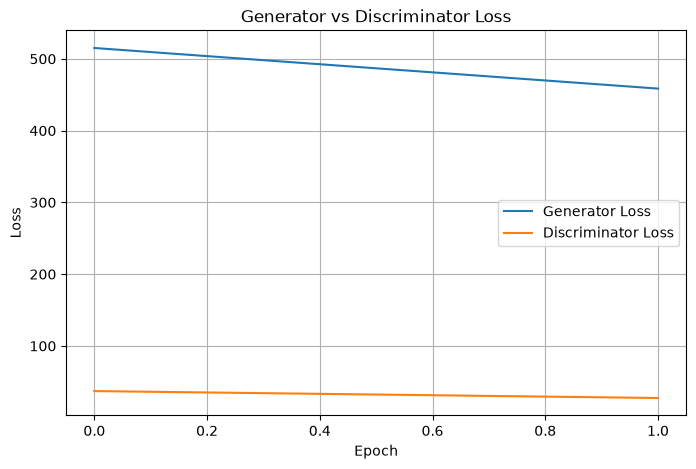

In [17]:
plt.figure(figsize=(8,5))

plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator vs Discriminator Loss")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
G_H2Z.eval()
G_Z2H.eval()

horse, zebra = next(iter(loader))

horse = horse.to(device)
zebra = zebra.to(device)

with torch.no_grad():
    fake_zebra = G_H2Z(horse)
    fake_horse = G_Z2H(zebra)

print("Sample images generated successfully!")

Sample images generated successfully!


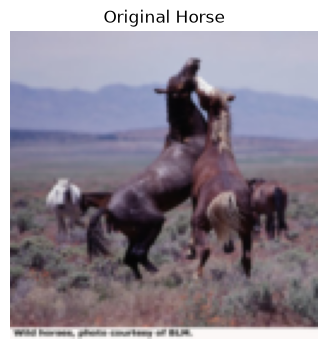

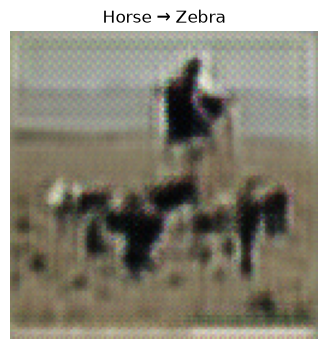

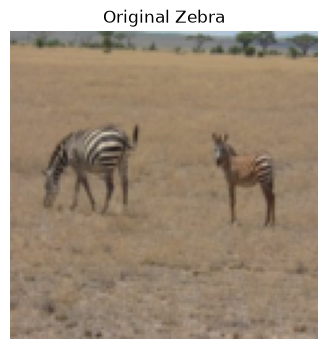

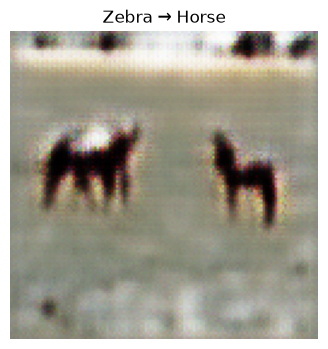

In [19]:
def show_image(tensor, title):

    image = tensor.cpu().detach()[0]
    image = image * 0.5 + 0.5
    image = image.permute(1,2,0)

    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()


show_image(horse, "Original Horse")
show_image(fake_zebra, "Horse → Zebra")

show_image(zebra, "Original Zebra")
show_image(fake_horse, "Zebra → Horse")

In [20]:
torch.save(G_H2Z.state_dict(), "generator_horse_to_zebra.pth")
torch.save(G_Z2H.state_dict(), "generator_zebra_to_horse.pth")

torch.save(D_H.state_dict(), "discriminator_horse.pth")
torch.save(D_Z.state_dict(), "discriminator_zebra.pth")

print("All models saved successfully!")

All models saved successfully!


## Cycle Consistency Loss

Cycle consistency loss helps the CycleGAN learn meaningful translations without requiring paired images. It ensures that if a horse image is translated into a zebra image and then translated back, the reconstructed image should closely resemble the original horse. The same process applies to zebra images. This constraint preserves the important structure and content of the image while allowing only the style to change. As a result, the model learns reliable image-to-image translation using unpaired datasets.